Here we will look at the effect of batch size on the learning of winedataset


In [60]:
import numpy as np 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from sklearn.datasets import load_wine
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [61]:
wine=load_wine()
X=torch.tensor(wine.data , dtype=torch.float32)
y=torch.tensor(wine.target , dtype=torch.long)
print(wine.DESCR)


.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [62]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train ,y_test=train_test_split(X,y , test_size=0.2 , random_state=101)

train_data=TensorDataset(X_train , y_train)
test_data=TensorDataset(X_test  , y_test)



In [63]:
class ANNmodel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.input=nn.Linear(13 , 50)
        self.output=nn.Linear(50 , 3)
    
    def forward(self , x):
        x=self.input(x)
        
        x=F.relu(x)
        
        x=self.output(x)
        
        return x

    
        
        

In [64]:
import time
def trainmodel(model , lossfn ,optimizer , train_loader , test_loader):
    epochs=400
    batch_acc=[]
    train_acc=[]
    test_acc=[]
    for i in range(epochs):
        start_time = time.time() 
        
        model.train()
        
        for X, y in train_loader :
            
            y_train_preds=model(X)
            loss=lossfn(y_train_preds , y)
            
            #backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            #calculating accuracy 
            labels = torch.argmax(y_train_preds, dim=1)
            batch_acc.append(100*(labels == y).float().mean().item())
            #end of batch loop
        
        end_time = time.time()  
        epoch_time = end_time - start_time
        
            
        #now train_acc
        train_acc.append(np.mean(batch_acc))
        
        #testing the model 
        model.eval()
        for X , y in test_loader :
            y_pred=model(X)
            labels = torch.argmax(y_pred, dim=1)
            test_acc.append(100*(labels == y).float().mean().item())
            
    return test_acc , train_acc , epoch_time
    
    
    

In [65]:
model = ANNmodel()
lossfn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

batches = np.linspace(1, 100, 10, dtype=int)
all_test_acc = []
all_train_acc = []
batch_list = []
time_per_epoch=[]
for i in batches:

    model = ANNmodel()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    i = int(i)

    train_loader = DataLoader(train_data, batch_size=i, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=len(test_data), shuffle=False)

    test_acc, train_acc , epoch_time = trainmodel(model, lossfn, optimizer, train_loader, test_loader)

    all_test_acc.append(np.mean(test_acc))   # last epoch accuracy
    all_train_acc.append(np.mean(train_acc))
    batch_list.append(i)
    time_per_epoch.append(np.mean(epoch_time))

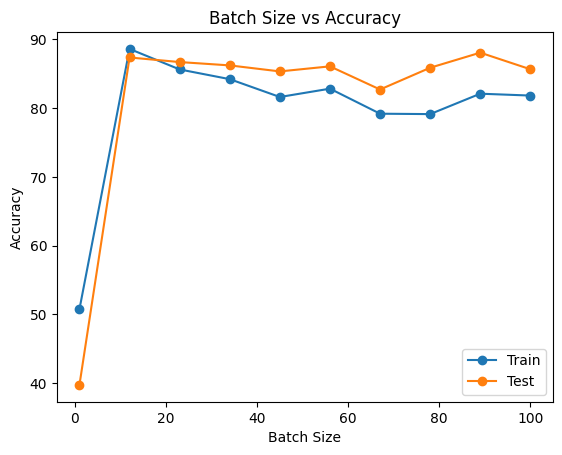

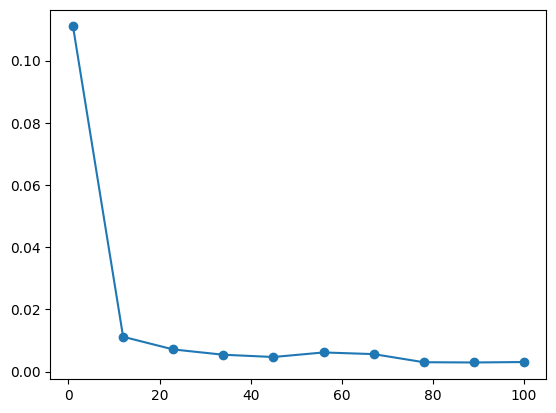

In [67]:
plt.figure()
plt.plot(batch_list, all_train_acc, marker='o')
plt.plot(batch_list, all_test_acc, marker='o')
plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.legend(["Train", "Test"])
plt.title("Batch Size vs Accuracy")
plt.figure()
plt.plot(batch_list, time_per_epoch, marker='o')
plt.show()

In [94]:
#can the model escape a local minima with a high learning rate 
model2 = ANNmodel()
lossfn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=100)

numepochs=5000
losses = []

for epochi in range(numepochs):

    # forward pass
    yHat = model(X)

    # compute loss
    loss = lossfn(yHat,y)
    losses.append(loss.item())

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
 

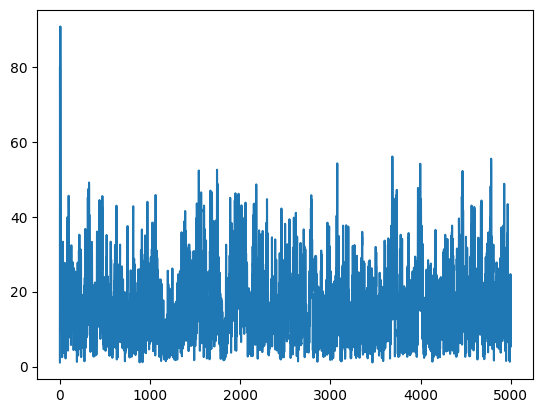

In [95]:

plt.figure()
plt.plot(range(5000),losses)

plt.show()